# Análisis Exploratorio de Datos — Countries of the World
**Autor:** José Gellida  
**Dataset:** [Countries of the World — Kaggle (fernandol)](https://www.kaggle.com/datasets/fernandol/countries-of-the-world)  
**Herramientas:** Python · Pandas · Seaborn · SciPy · Plotly  

---
> Este análisis forma parte de mi portfolio de Data Science con enfoque en economía y finanzas globales.

## 0. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# Estilo visual consistente
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


---
## 1. Introducción

### 1a. Descripción de la base de datos

El dataset **"Countries of the World"** fue publicado por Fernando Lasso en Kaggle en 2018 y agrupa información demográfica, económica y social de **227 países e islas independientes** del mundo. Los datos provienen originalmente de fuentes gubernamentales de EE.UU. y han sido ampliamente utilizados en proyectos académicos de estadística descriptiva y ciencia de datos.

**Propósito del análisis:** Identificar patrones económicos y demográficos globales, explorar las relaciones entre indicadores de desarrollo (GDP, alfabetización, mortalidad infantil) y construir una base sólida para futuros modelos predictivos.

### 1b. Descripción de las variables

In [2]:
# ⚠️ IMPORTANTE: el separador decimal es coma (formato europeo)
# Asegúrate de que el archivo esté en la misma carpeta que este notebook
df = pd.read_csv('countries of the world.csv', decimal=',')

# Limpieza de nombres de columnas y valores de texto
df.columns = df.columns.str.strip()
df['Country'] = df['Country'].str.strip()
df['Region']  = df['Region'].str.strip()

print(f'Dimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head()

Dimensiones del dataset: 227 filas × 20 columnas


,Country,Region,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
0,Afghanistan,ASIA (EX. NEAR EAST),31056997,647500,48.0,0.00,23.06,163.07,700.0,36.0,3.2,12.13,0.22,87.65,1.0,46.60,20.34,0.380,0.240,0.380
1,Albania,EASTERN EUROPE,3581655,28748,124.6,1.26,-4.93,21.52,4500.0,86.5,71.2,21.09,4.42,74.49,3.0,15.11,5.22,0.232,0.188,0.579
2,Algeria,NORTHERN AFRICA,32930091,2381740,13.8,0.04,-0.39,31.00,6000.0,70.0,78.1,3.22,0.25,96.53,1.0,17.14,4.61,0.101,0.600,0.298
3,American Samoa,OCEANIA,57794,199,290.4,58.29,-20.71,9.27,8000.0,97.0,259.5,10.00,15.00,75.00,2.0,22.46,3.27,NaN,NaN,NaN
4,Andorra,WESTERN EUROPE,71201,468,152.1,0.00,6.60,4.05,19000.0,100.0,497.2,2.22,0.00,97.78,3.0,8.71,6.25,NaN,NaN,NaN


In [26]:
# Tabla descriptiva de variables originales del dataset
variables_originales = [
    'Country', 'Region', 'Population', 'Area (sq. mi.)',
    'Pop. Density (per sq. mi.)', 'Coastline (coast/area ratio)',
    'Net migration', 'Infant mortality (per 1000 births)',
    'GDP ($ per capita)', 'Literacy (%)', 'Phones (per 1000)',
    'Arable (%)', 'Crops (%)', 'Other (%)', 'Climate',
    'Birthrate', 'Deathrate', 'Agriculture', 'Industry', 'Service'
 ]

descripcion_map = {
    'Country': 'Nombre del país',
    'Region': 'Región geográfica',
    'Population': 'Población total',
    'Area (sq. mi.)': 'Superficie en millas cuadradas',
    'Pop. Density (per sq. mi.)': 'Densidad de población',
    'Coastline (coast/area ratio)': 'Ratio costa/área',
    'Net migration': 'Migración neta',
    'Infant mortality (per 1000 births)': 'Mortalidad infantil por 1.000 nacimientos',
    'GDP ($ per capita)': 'GDP per cápita en USD',
    'Literacy (%)': 'Tasa de alfabetización (%)',
    'Phones (per 1000)': 'Teléfonos por 1.000 habitantes',
    'Arable (%)': 'Tierra arable (%)',
    'Crops (%)': 'Cultivos (%)',
    'Other (%)': 'Otros usos del suelo (%)',
    'Climate': 'Clima (código)',
    'Birthrate': 'Tasa de natalidad',
    'Deathrate': 'Tasa de mortalidad',
    'Agriculture': 'Peso del sector agrícola en el GDP',
    'Industry': 'Peso del sector industrial en el GDP',
    'Service': 'Peso del sector servicios en el GDP'
}

descripcion_vars = pd.DataFrame({
    'Variable': variables_originales,
    'Tipo': df[variables_originales].dtypes.astype(str).values,
    'Descripción': [descripcion_map[col] for col in variables_originales]
})

display(descripcion_vars)

,Variable,Tipo,Descripción
0,Country,str,Nombre del país
1,Region,str,Región geográfica
2,Population,int64,Población total
3,Area (sq. mi.),int64,Superficie en millas cuadradas
4,Pop. Density (per sq. mi.),float64,Densidad de población
5,Coastline (coast/area ratio),float64,Ratio costa/área
6,Net migration,float64,Migración neta
7,Infant mortality (per 1000 births),float64,Mortalidad infantil por 1.000 nacimientos
8,GDP ($ per capita),float64,GDP per cápita en USD
9,Literacy (%),float64,Tasa de alfabetización (%)


In [3]:
# Descripción de tipos y valores nulos
info = pd.DataFrame({
    'Tipo':    df.dtypes,
    'No nulos': df.notnull().sum(),
    'Nulos':   df.isnull().sum(),
    '% Nulos': (df.isnull().sum() / len(df) * 100).round(1)
})
print(info.to_string())

                                       Tipo  No nulos  Nulos  % Nulos
Country                                 str       227      0      0.0
Region                                  str       227      0      0.0
Population                            int64       227      0      0.0
Area (sq. mi.)                        int64       227      0      0.0
Pop. Density (per sq. mi.)          float64       227      0      0.0
Coastline (coast/area ratio)        float64       227      0      0.0
Net migration                       float64       224      3      1.3
Infant mortality (per 1000 births)  float64       224      3      1.3
GDP ($ per capita)                  float64       226      1      0.4
Literacy (%)                        float64       209     18      7.9
Phones (per 1000)                   float64       223      4      1.8
Arable (%)                          float64       225      2      0.9
Crops (%)                           float64       225      2      0.9
Other (%)           

In [4]:
# Eliminamos filas con demasiados valores nulos (menos de 15 columnas completas)
df.dropna(thresh=15, inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Dataset tras limpieza: {df.shape[0]} países')

Dataset tras limpieza: 224 países


---
## 2. Análisis descriptivo de variables cuantitativas

### 2a. Selección de variables

| Variable | Descripción |
|---|---|
| `GDP ($ per capita)` | Producto Interior Bruto per cápita en USD |
| `Literacy (%)` | Tasa de alfabetización de la población adulta |
| `Infant mortality (per 1000 births)` | Mortalidad infantil por cada 1.000 nacimientos |
| `Phones (per 1000)` | Teléfonos por cada 1.000 habitantes |
| `Birthrate` | Tasa de natalidad por cada 1.000 habitantes |

In [5]:
VARS_CUANT = [
    'GDP ($ per capita)',
    'Literacy (%)',
    'Infant mortality (per 1000 births)',
    'Phones (per 1000)',
    'Birthrate'
]

# Renombres cortos para gráficos
LABELS = {
    'GDP ($ per capita)': 'GDP per cápita',
    'Literacy (%)': 'Alfabetización (%)',
    'Infant mortality (per 1000 births)': 'Mortalidad infantil',
    'Phones (per 1000)': 'Teléfonos/1000',
    'Birthrate': 'Natalidad'
}

### 2b–2c. Medidas de tendencia central y dispersión

In [6]:
desc = df[VARS_CUANT].describe().T
desc.columns = ['N', 'Media', 'Desv. Std', 'Mín', 'P25', 'Mediana', 'P75', 'Máx']

# Añadimos moda, varianza y rango
desc['Moda']     = [df[v].mode()[0] for v in VARS_CUANT]
desc['Varianza'] = df[VARS_CUANT].var().values
desc['Rango']    = desc['Máx'] - desc['Mín']

desc.index = [LABELS[v] for v in VARS_CUANT]
desc.round(2)

,N,Media,Desv. Std,Mín,P25,Mediana,P75,Máx,Moda,Varianza,Rango
GDP per cápita,224.0,9748.21,10074.78,500.00,1900.00,5700.00,15775.00,55100.00,800.00,1.015012e+08,54600.00
Alfabetización (%),208.0,83.00,19.64,17.60,73.30,92.50,98.00,100.00,99.00,3.856100e+02,82.40
Mortalidad infantil,223.0,35.39,35.42,2.29,8.11,20.97,55.33,191.19,9.95,1.254810e+03,188.90
Teléfonos/1000,221.0,237.44,228.54,0.20,37.20,179.00,394.40,1035.60,2.30,5.223034e+04,1035.40
Natalidad,223.0,22.03,11.13,7.29,12.64,18.79,29.77,50.73,12.56,1.238800e+02,43.44


**Interpretación (2c):**
- Los percentiles 25 y 75 del GDP (1.900$ y 15.775$ respectivamente) revelan una distribución altamente asimétrica, con una gran concentración de países en tramos bajos-medios y una cola larga hacia valores altos.
- Esta brecha entre P25 y P75 refuerza la necesidad de complementar la media con medidas robustas (mediana y rango intercuartílico) al analizar desarrollo económico global.

### 2d. Visualización: histogramas, boxplots y densidad

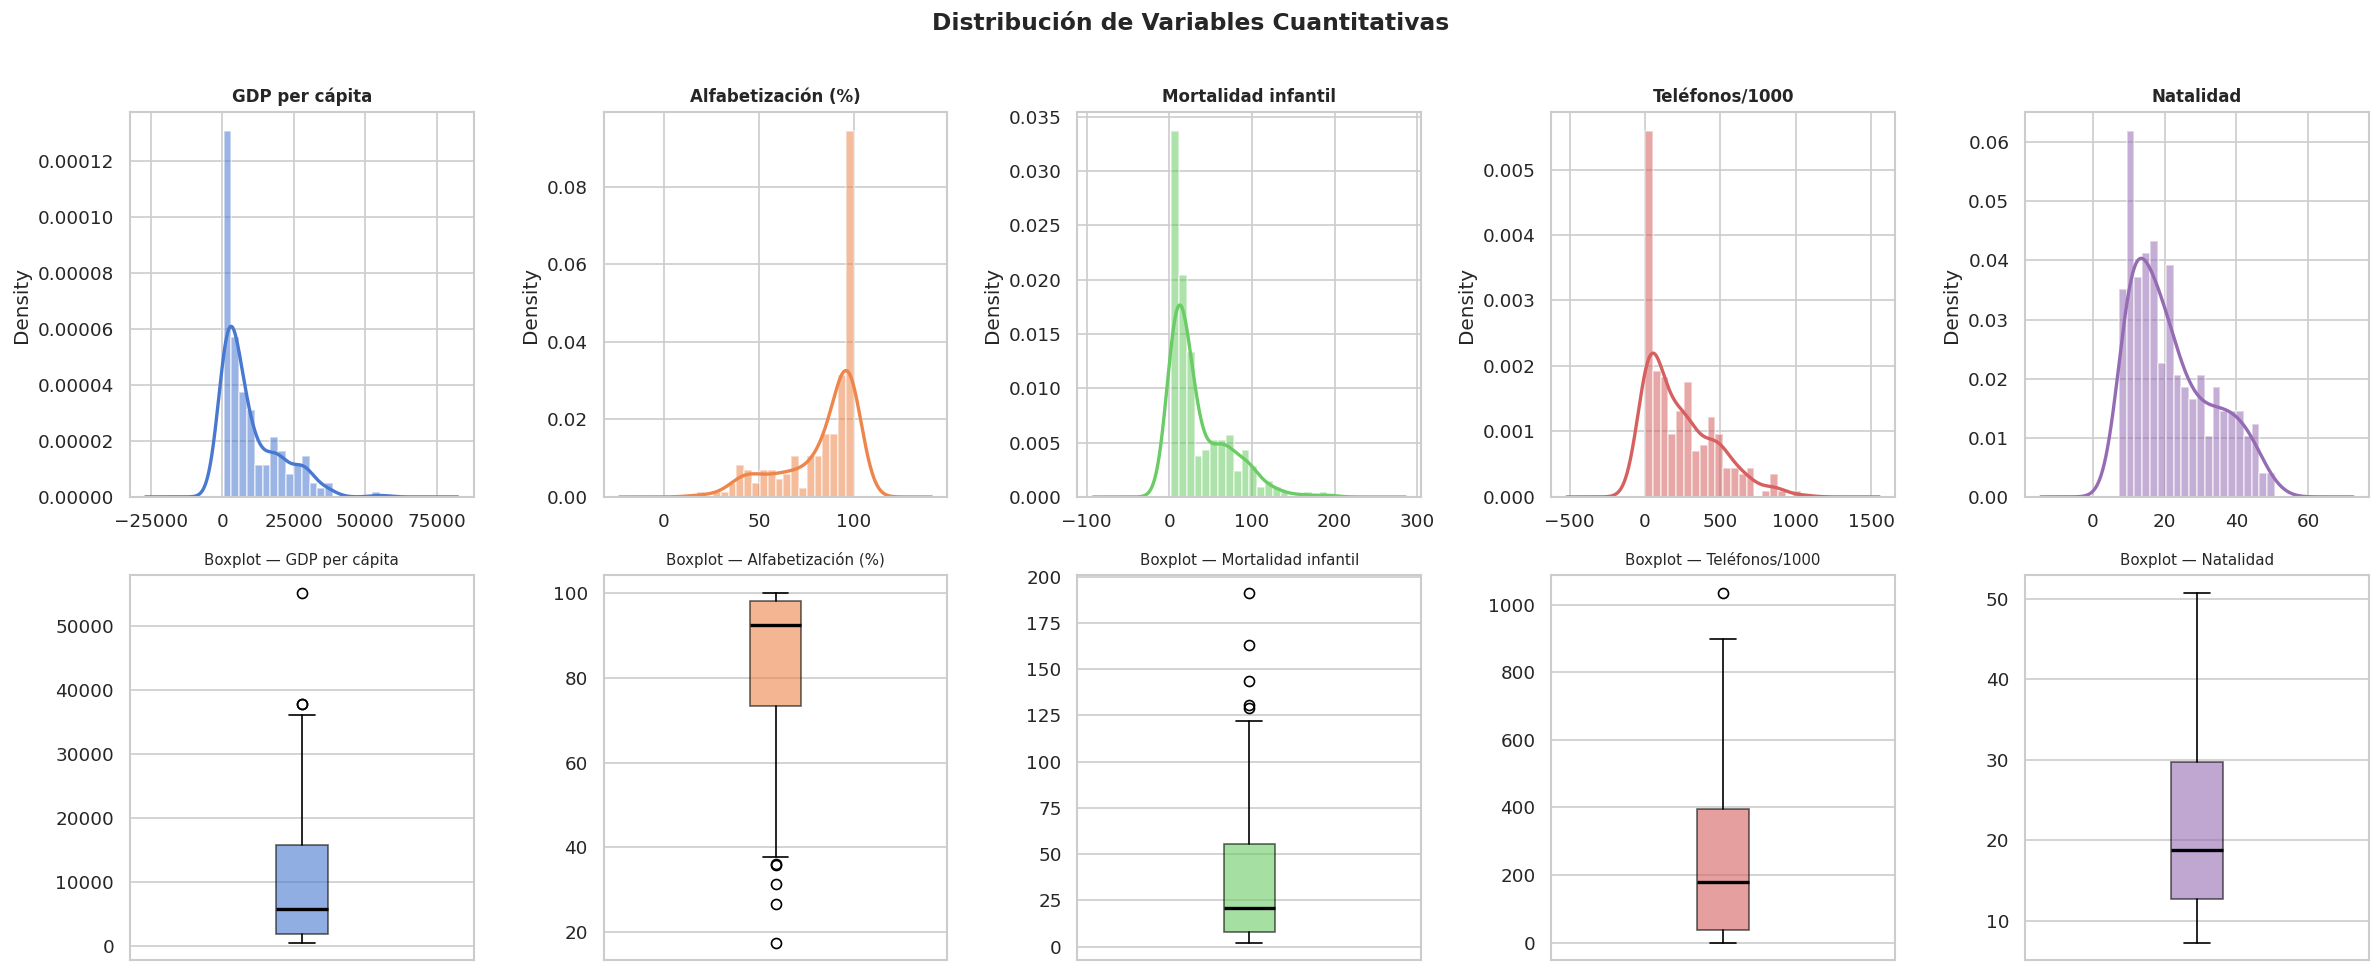

In [27]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
colors = sns.color_palette('muted', 5)

for i, var in enumerate(VARS_CUANT):
    data = df[var].dropna()
    label = LABELS[var]

    # Fila 0: Histograma + KDE
    axes[0, i].hist(data, bins=20, density=True, alpha=0.55, color=colors[i], edgecolor='white')
    data.plot(kind='kde', ax=axes[0, i], color=colors[i], linewidth=2)
    axes[0, i].set_title(label, fontsize=10, fontweight='bold')
    axes[0, i].set_xlabel('')

    # Fila 1: Boxplot
    axes[1, i].boxplot(data.values, patch_artist=True,
                       boxprops=dict(facecolor=colors[i], alpha=0.6),
                       medianprops=dict(color='black', linewidth=2))
    axes[1, i].set_title(f'Boxplot — {label}', fontsize=9)
    axes[1, i].set_xticks([])

fig.suptitle('Distribución de Variables Cuantitativas', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('histogramas_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

### 2e. Verificación de normalidad: Shapiro-Wilk y Kolmogorov-Smirnov

In [8]:
resultados_normalidad = []

for var in VARS_CUANT:
    data = df[var].dropna()
    _, p_sw = stats.shapiro(data[:5000])   # Shapiro: máximo 5000 obs
    _, p_ks = stats.kstest(data, 'norm', args=(data.mean(), data.std()))
    resultados_normalidad.append({
        'Variable': LABELS[var],
        'Shapiro-Wilk p': round(p_sw, 4),
        'KS p': round(p_ks, 4),
        'SW Normal (α=0.05)': '✓ Sí' if p_sw > 0.05 else '✗ No',
        'KS Normal (α=0.05)': '✓ Sí' if p_ks > 0.05 else '✗ No'
    })

pd.DataFrame(resultados_normalidad).set_index('Variable')

,Shapiro-Wilk p,KS p,SW Normal (α=0.05),KS Normal (α=0.05)
Variable,,,,
GDP per cápita,0.0,0.0000,✗ No,✗ No
Alfabetización (%),0.0,0.0000,✗ No,✗ No
Mortalidad infantil,0.0,0.0000,✗ No,✗ No
Teléfonos/1000,0.0,0.0001,✗ No,✗ No
Natalidad,0.0,0.0018,✗ No,✗ No


### 2f. Interpretación

> **Comentario:** Ninguna de las variables económicas sigue una distribución normal, lo cual es esperable en datos macroeconómicos reales. El GDP per cápita, en particular, muestra una distribución fuertemente asimétrica a la derecha (log-normal), con un pequeño grupo de países de renta muy alta que actúan como outliers extremos. Esto implica que para futuros análisis inferenciales debería considerarse la transformación logarítmica del GDP o el uso de pruebas no paramétricas.

---
## 3. Análisis descriptivo de variables categóricas

### 3a. Selección y creación de variables categóricas

El dataset incluye `Region` como variable categórica nativa. Las otras dos las derivamos de variables cuantitativas con umbrales justificados por estándares internacionales (Banco Mundial, UNESCO).

In [9]:
# Categórica 1 (nativa): Región
# Categórica 2: Nivel de desarrollo — umbrales Banco Mundial 2024
df['nivel_desarrollo'] = pd.cut(
    df['GDP ($ per capita)'],
    bins=[0, 3000, 12000, float('inf')],
    labels=['Bajo (<3.000$)', 'Medio (3k–12k$)', 'Alto (>12.000$)']
)

# Categórica 3: Nivel de alfabetización — referencia UNESCO
df['nivel_alfabetizacion'] = pd.cut(
    df['Literacy (%)'],
    bins=[0, 60, 85, 100],
    labels=['Baja (<60%)', 'Media (60–85%)', 'Alta (>85%)']
)

VARS_CAT = ['Region', 'nivel_desarrollo', 'nivel_alfabetizacion']
print('Variables categóricas definidas ✅')

Variables categóricas definidas ✅


### 3b. Frecuencias absolutas y relativas

In [10]:
for var in VARS_CAT:
    freq = pd.DataFrame({
        'Absoluta': df[var].value_counts(),
        'Relativa (%)': (df[var].value_counts(normalize=True) * 100).round(1)
    })
    print(f'\n📊 {var}\n{freq.to_string()}')


📊 Region
                      Absoluta  Relativa (%)
Region                                      
SUB-SAHARAN AFRICA          50          22.3
LATIN AMER. & CARIB         45          20.1
ASIA (EX. NEAR EAST)        28          12.5
WESTERN EUROPE              28          12.5
OCEANIA                     20           8.9
NEAR EAST                   16           7.1
EASTERN EUROPE              12           5.4
C.W. OF IND. STATES         12           5.4
NORTHERN AFRICA              5           2.2
NORTHERN AMERICA             5           2.2
BALTICS                      3           1.3

📊 nivel_desarrollo
                  Absoluta  Relativa (%)
nivel_desarrollo                        
Bajo (<3.000$)          79          35.3
Medio (3k–12k$)         79          35.3
Alto (>12.000$)         66          29.5

📊 nivel_alfabetizacion
                      Absoluta  Relativa (%)
nivel_alfabetizacion                        
Alta (>85%)                132          63.5
Media (60–85%)       

### 3c. Visualización: barras, tarta y mosaico

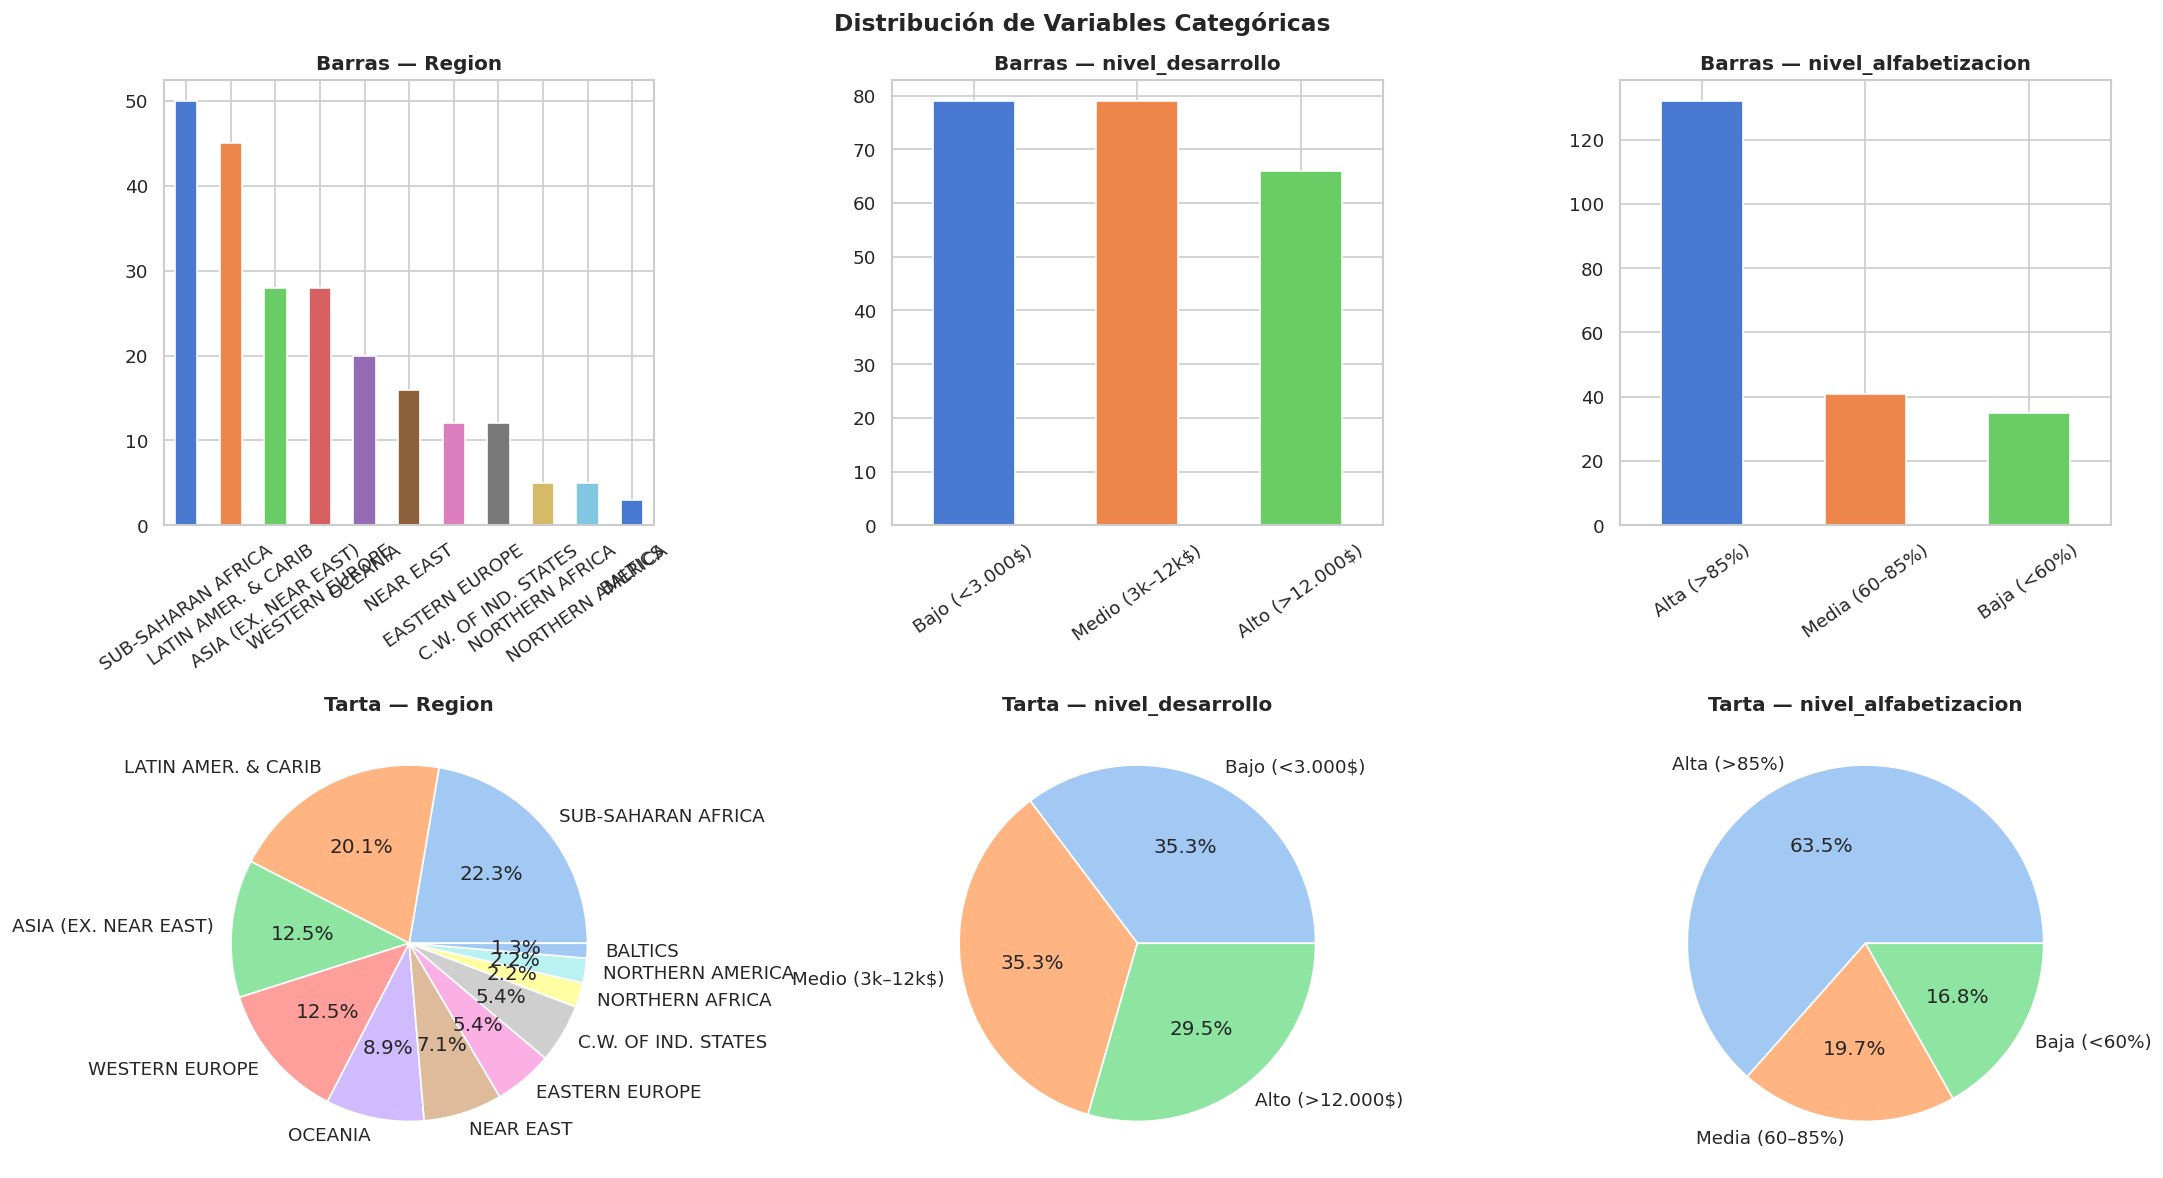

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col_i, var in enumerate(VARS_CAT):
    freq = df[var].value_counts()

    # Barras
    freq.plot(kind='bar', ax=axes[0, col_i], color=sns.color_palette('muted', len(freq)))
    axes[0, col_i].set_title(f'Barras — {var}', fontweight='bold')
    axes[0, col_i].set_xlabel('')
    axes[0, col_i].tick_params(axis='x', rotation=35)

    # Tarta
    axes[1, col_i].pie(freq, labels=freq.index, autopct='%1.1f%%',
                       colors=sns.color_palette('pastel', len(freq)))
    axes[1, col_i].set_title(f'Tarta — {var}', fontweight='bold')

fig.suptitle('Distribución de Variables Categóricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('categoricas_barras_tarta.png', dpi=150, bbox_inches='tight')
plt.show()

### 3d. Tablas de contingencia y prueba Chi-cuadrado

In [12]:
# Tabla de contingencia: Región vs Nivel de desarrollo
tabla_cont = pd.crosstab(df['Region'], df['nivel_desarrollo'], margins=True)
print('Tabla de contingencia: Región × Nivel de Desarrollo')
display(tabla_cont)

Tabla de contingencia: Región × Nivel de Desarrollo


nivel_desarrollo,Bajo (<3.000$),Medio (3k–12k$),Alto (>12.000$),All
Region,,,,
ASIA (EX. NEAR EAST),13,8,7,28
BALTICS,0,2,1,3
C.W. OF IND. STATES,5,7,0,12
EASTERN EUROPE,1,7,4,12
LATIN AMER. & CARIB,6,30,9,45
NEAR EAST,4,5,7,16
NORTHERN AFRICA,0,5,0,5
NORTHERN AMERICA,0,1,4,5
OCEANIA,8,6,6,20


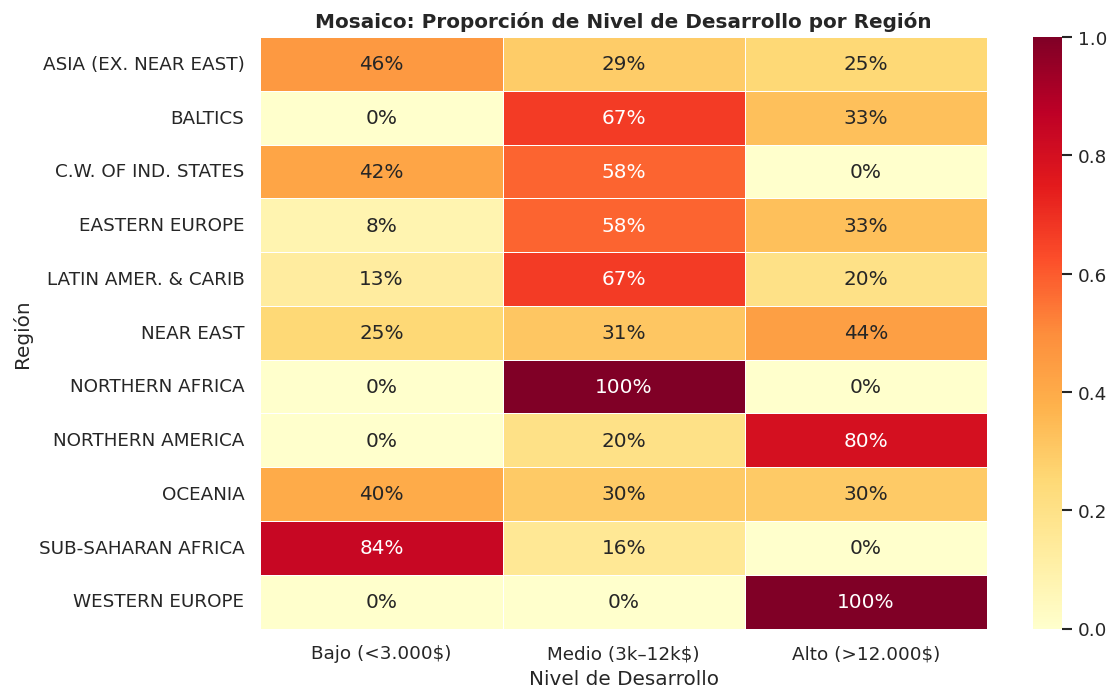

In [13]:
# Visualización tipo mosaico (heatmap normalizado)
tabla_norm = pd.crosstab(df['Region'], df['nivel_desarrollo'], normalize='index').round(2)

plt.figure(figsize=(10, 6))
sns.heatmap(tabla_norm, annot=True, fmt='.0%', cmap='YlOrRd',
            linewidths=0.5, linecolor='white')
plt.title('Mosaico: Proporción de Nivel de Desarrollo por Región', fontweight='bold')
plt.ylabel('Región')
plt.xlabel('Nivel de Desarrollo')
plt.tight_layout()
plt.savefig('mosaico_region_desarrollo.png', dpi=150, bbox_inches='tight')
plt.show()

### 3e. Chi-cuadrado, Coeficiente de Contingencia y Cramér's V

In [14]:
pares_cat = [
    ('Region', 'nivel_desarrollo'),
    ('Region', 'nivel_alfabetizacion'),
    ('nivel_desarrollo', 'nivel_alfabetizacion')
]

resultados_chi = []
for v1, v2 in pares_cat:
    tabla = pd.crosstab(df[v1], df[v2])
    chi2, p, dof, _ = stats.chi2_contingency(tabla)
    n = tabla.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(tabla.shape) - 1)))
    coef_cont  = np.sqrt(chi2 / (chi2 + n))
    resultados_chi.append({
        'Par': f'{v1} × {v2}',
        'Chi²': round(chi2, 3),
        'p-valor': round(p, 4),
        'gl': dof,
        'Coef. Contingencia': round(coef_cont, 3),
        "Cramér's V": round(cramers_v, 3),
        'Significativo': '✓ Sí' if p < 0.05 else '✗ No'
    })

pd.DataFrame(resultados_chi).set_index('Par')

,Chi²,p-valor,gl,Coef. Contingencia,Cramér's V,Significativo
Par,,,,,,
Region × nivel_desarrollo,171.602,0.0,20,0.659,0.619,✓ Sí
Region × nivel_alfabetizacion,111.315,0.0,20,0.590,0.517,✓ Sí
nivel_desarrollo × nivel_alfabetizacion,82.028,0.0,4,0.532,0.444,✓ Sí


**Interpretación de Cramér's V (3e):**
El par **Región × nivel_desarrollo** obtiene un **Cramér's V = 0.619**, lo que indica una asociación fuerte entre ambas variables. Esto confirma que la región geográfica de un país es un predictor relevante de su nivel de desarrollo económico.

El par **nivel_desarrollo × nivel_alfabetizacion** obtiene **V = 0.444**, lo que sugiere una asociación moderada-alta, coherente con la teoría del capital humano: mayores niveles de educación suelen acompañarse de mejores resultados económicos.

---
## 4. Análisis descriptivo de variables binarias

### 4a. Creación y justificación de variables binarias

| Variable binaria | Criterio | Fuente del umbral |
|---|---|---|
| `es_desarrollado` | GDP per cápita > 12.000$ | Banco Mundial (renta alta) |
| `alta_mortalidad` | Mortalidad infantil > 30/1.000 | OMS |
| `alta_alfabetizacion` | Tasa de alfabetización > 90% | UNESCO |

In [15]:
df['es_desarrollado']      = (df['GDP ($ per capita)'] > 12000).astype(int)
df['alta_mortalidad']      = (df['Infant mortality (per 1000 births)'] > 30).astype(int)
df['alta_alfabetizacion']  = (df['Literacy (%)'] > 90).astype(int)

VARS_BIN = ['es_desarrollado', 'alta_mortalidad', 'alta_alfabetizacion']
print('Variables binarias creadas ✅')

Variables binarias creadas ✅


### 4b. Proporciones y frecuencias

In [16]:
resumen_bin = pd.DataFrame({
    'Variable': VARS_BIN,
    'N (=1)': [df[v].sum() for v in VARS_BIN],
    'N (=0)': [(df[v] == 0).sum() for v in VARS_BIN],
    'Proporción (=1)': [df[v].mean().round(3) for v in VARS_BIN],
    'Proporción (=0)': [(1 - df[v].mean()).round(3) for v in VARS_BIN]
}).set_index('Variable')
resumen_bin

,N (=1),N (=0),Proporción (=1),Proporción (=0)
Variable,,,,
es_desarrollado,66,158,0.295,0.705
alta_mortalidad,82,142,0.366,0.634
alta_alfabetizacion,114,110,0.509,0.491


### 4c. Visualización: gráficos de barras

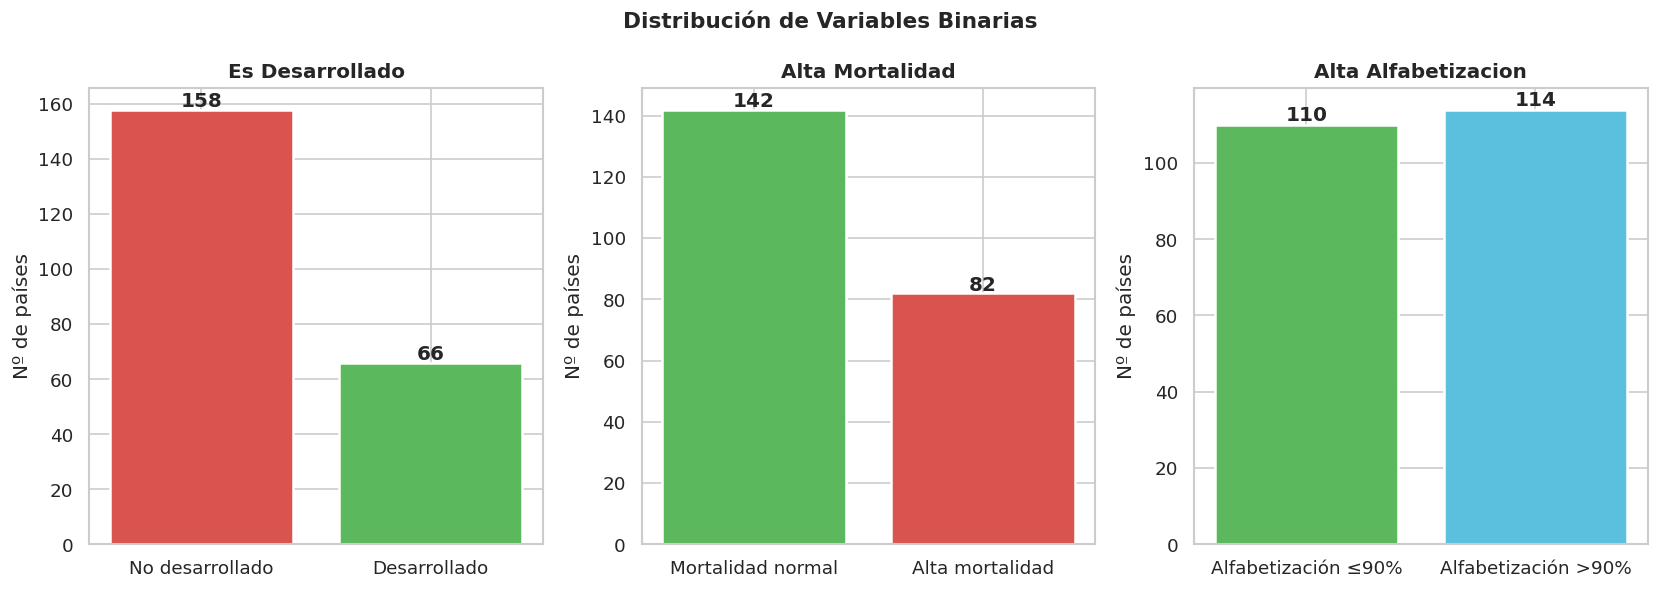

In [17]:
etiquetas_bin = {
    'es_desarrollado': ['No desarrollado', 'Desarrollado'],
    'alta_mortalidad': ['Mortalidad normal', 'Alta mortalidad'],
    'alta_alfabetizacion': ['Alfabetización ≤90%', 'Alfabetización >90%']
}

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colores = [('#D9534F', '#5CB85C'), ('#5CB85C', '#D9534F'), ('#5CB85C', '#5BC0DE')]

for i, var in enumerate(VARS_BIN):
    counts = df[var].value_counts().sort_index()
    bars = axes[i].bar(etiquetas_bin[var], counts.values,
                       color=colores[i], edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, counts.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     str(val), ha='center', fontweight='bold')
    axes[i].set_title(var.replace('_', ' ').title(), fontweight='bold')
    axes[i].set_ylabel('Nº de países')

fig.suptitle('Distribución de Variables Binarias', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('binarias_barras.png', dpi=150, bbox_inches='tight')
plt.show()

### 4d. Tablas de contingencia 2×2
### 4e. Coeficiente Phi

In [24]:
# Tabla de contingencia: es_desarrollado × alta_mortalidad
tabla_bin = pd.crosstab(
    df['es_desarrollado'],
    df['alta_mortalidad'],
    rownames=['es_desarrollado'],
    colnames=['alta_mortalidad'],
    margins=True
)
display(tabla_bin)

# Tabla de contingencia: es_desarrollado × alta_alfabetizacion
tabla_bin = pd.crosstab(
    df['es_desarrollado'],
    df['alta_alfabetizacion'],
    rownames=['es_desarrollado'],
    colnames=['alta_alfabetizacion'],
    margins=True
)
display(tabla_bin)

# Tabla de contingencia: alta_mortalidad × alta_alfabetizacion
tabla_bin = pd.crosstab(
    df['alta_mortalidad'],
    df['alta_alfabetizacion'],
    rownames=['alta_mortalidad'],
    colnames=['alta_alfabetizacion'],
    margins=True
)
display(tabla_bin)

alta_mortalidad,0,1,All
es_desarrollado,,,
0,76,82,158
1,66,0,66
All,142,82,224


alta_alfabetizacion,0,1,All
es_desarrollado,,,
0,97,61,158
1,13,53,66
All,110,114,224


alta_alfabetizacion,0,1,All
alta_mortalidad,,,
0,39,103,142
1,71,11,82
All,110,114,224


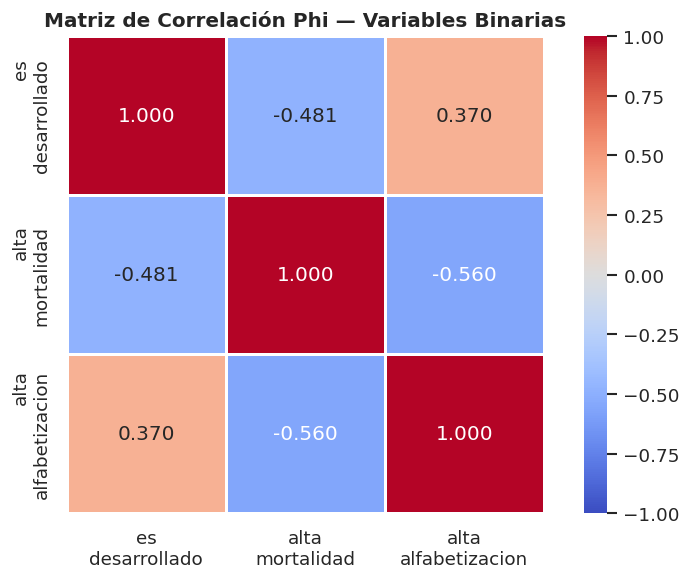

In [18]:
# Coeficiente Phi para todos los pares
phi_matrix = pd.DataFrame(np.eye(3), index=VARS_BIN, columns=VARS_BIN)

for v1, v2 in combinations(VARS_BIN, 2):
    tabla = pd.crosstab(df[v1], df[v2])
    chi2, _, _, _ = stats.chi2_contingency(tabla)
    n = tabla.sum().sum()
    phi = np.sqrt(chi2 / n)
    # Signo: negativo si la correlación es inversa
    r = np.corrcoef(df[v1].fillna(0), df[v2].fillna(0))[0, 1]
    phi_signed = phi * np.sign(r)
    phi_matrix.loc[v1, v2] = phi_signed
    phi_matrix.loc[v2, v1] = phi_signed

# Visualización
plt.figure(figsize=(7, 5))
sns.heatmap(phi_matrix.astype(float), annot=True, fmt='.3f',
            cmap='coolwarm', vmin=-1, vmax=1,
            square=True, linewidths=0.8, linecolor='white',
            xticklabels=[v.replace('_', '\n') for v in VARS_BIN],
            yticklabels=[v.replace('_', '\n') for v in VARS_BIN])
plt.title('Matriz de Correlación Phi — Variables Binarias', fontweight='bold')
plt.tight_layout()
plt.savefig('phi_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### 4f. Prueba t-Student: GDP entre países desarrollados vs no desarrollados

In [19]:
var_continua = 'GDP ($ per capita)'
var_bin_ref  = 'es_desarrollado'

grupo_0 = df[df[var_bin_ref] == 0][var_continua].dropna()
grupo_1 = df[df[var_bin_ref] == 1][var_continua].dropna()

t_stat, p_val = stats.ttest_ind(grupo_0, grupo_1, equal_var=False)  # Welch's t-test

print(f'Grupo No Desarrollado — Media GDP: {grupo_0.mean():,.0f}$  (n={len(grupo_0)})')
print(f'Grupo Desarrollado    — Media GDP: {grupo_1.mean():,.0f}$  (n={len(grupo_1)})')
print(f'\nt de Welch = {t_stat:.4f}')
print(f'p-valor    = {p_val:.6f}')
print(f'\n→ {"Diferencia SIGNIFICATIVA (p < 0.05)" if p_val < 0.05 else "Sin diferencia significativa"}')

Grupo No Desarrollado — Media GDP: 4,093$  (n=158)
Grupo Desarrollado    — Media GDP: 23,286$  (n=66)

t de Welch = -19.3990
p-valor    = 0.000000

→ Diferencia SIGNIFICATIVA (p < 0.05)


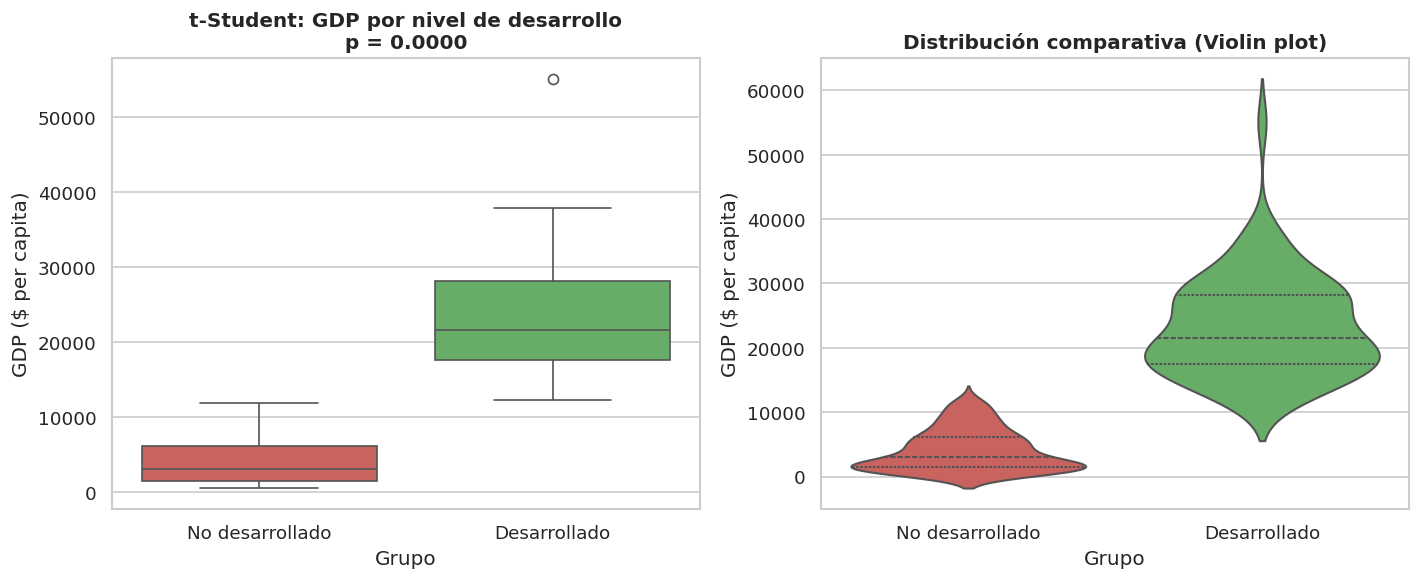

In [20]:
# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

data_plot = df[[var_continua, var_bin_ref]].dropna()
grupos_labels = {0: 'No desarrollado', 1: 'Desarrollado'}
data_plot['Grupo'] = data_plot[var_bin_ref].map(grupos_labels)

sns.boxplot(data=data_plot, x='Grupo', y=var_continua, ax=axes[0],
            palette={'No desarrollado': '#D9534F', 'Desarrollado': '#5CB85C'})
axes[0].set_title(f't-Student: GDP por nivel de desarrollo\np = {p_val:.4f}', fontweight='bold')

sns.violinplot(data=data_plot, x='Grupo', y=var_continua, ax=axes[1],
               palette={'No desarrollado': '#D9534F', 'Desarrollado': '#5CB85C'},
               inner='quartile')
axes[1].set_title('Distribución comparativa (Violin plot)', fontweight='bold')

plt.tight_layout()
plt.savefig('ttest_gdp.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Relaciones entre variables cuantitativas

### 5a. Matriz de correlación de Pearson

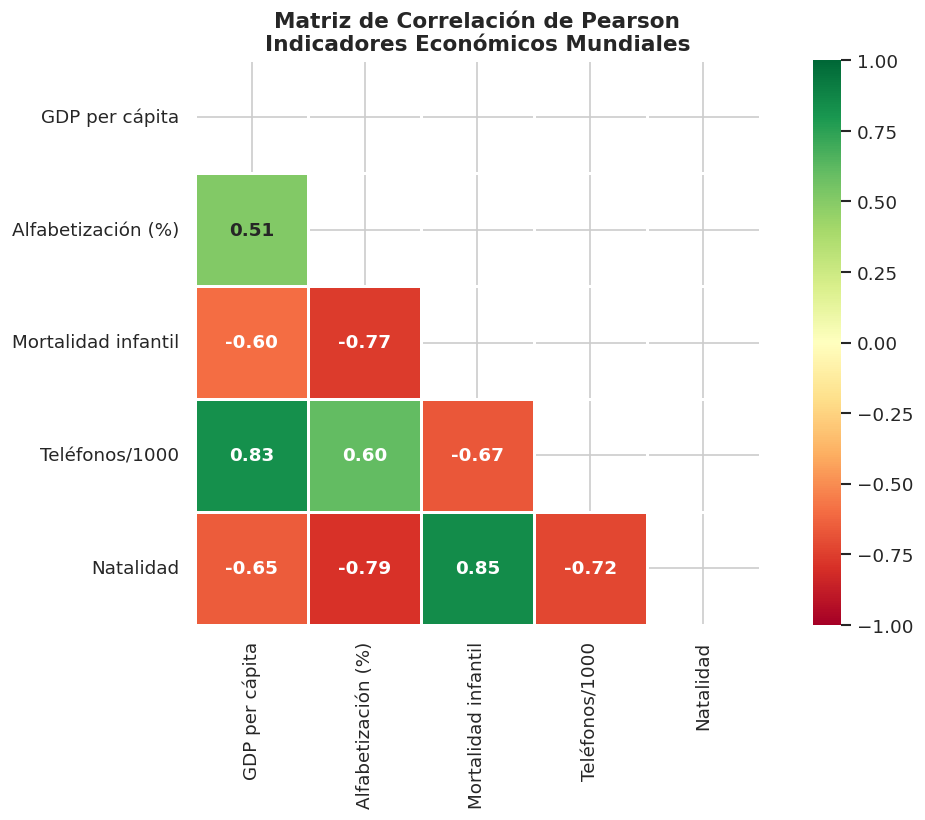

In [21]:
corr_matrix = df[VARS_CUANT].corr(method='pearson')

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', vmin=-1, vmax=1,
            square=True, linewidths=0.8, linecolor='white',
            xticklabels=[LABELS[v] for v in VARS_CUANT],
            yticklabels=[LABELS[v] for v in VARS_CUANT],
            annot_kws={'size': 11, 'weight': 'bold'})
plt.title('Matriz de Correlación de Pearson\nIndicadores Económicos Mundiales',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlacion_pearson.png', dpi=150, bbox_inches='tight')
plt.show()

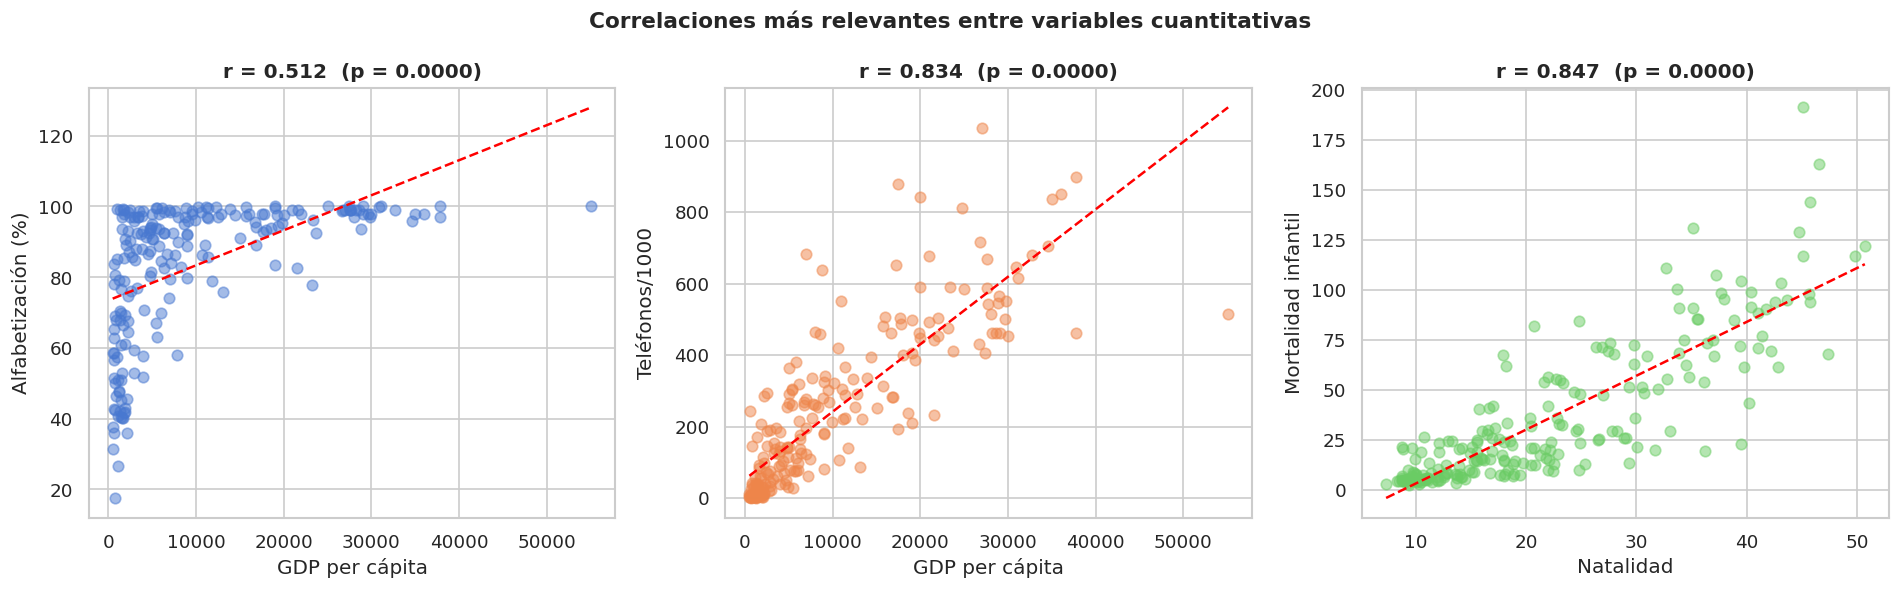

In [22]:
# Scatter plots de los pares más relevantes
pares_scatter = [
    ('GDP ($ per capita)', 'Literacy (%)'),
    ('GDP ($ per capita)', 'Phones (per 1000)'),
    ('Birthrate', 'Infant mortality (per 1000 births)')
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (x_var, y_var) in enumerate(pares_scatter):
    data = df[[x_var, y_var]].dropna()
    r, p = stats.pearsonr(data[x_var], data[y_var])

    axes[i].scatter(data[x_var], data[y_var], alpha=0.5, s=40,
                    color=sns.color_palette('muted')[i])
    # Línea de tendencia
    m, b = np.polyfit(data[x_var], data[y_var], 1)
    x_line = np.linspace(data[x_var].min(), data[x_var].max(), 100)
    axes[i].plot(x_line, m * x_line + b, color='red', linewidth=1.5, linestyle='--')

    axes[i].set_xlabel(LABELS[x_var])
    axes[i].set_ylabel(LABELS[y_var])
    axes[i].set_title(f'r = {r:.3f}  (p = {p:.4f})', fontweight='bold')

fig.suptitle('Correlaciones más relevantes entre variables cuantitativas',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🗺️ EXTRA (Portfolio): Mapa coroplético mundial con Plotly

In [23]:
try:
    import plotly.express as px

    fig_map = px.choropleth(
        df,
        locations='Country',
        locationmode='country names',
        color='GDP ($ per capita)',
        color_continuous_scale='Viridis',
        hover_name='Country',
        hover_data={'Literacy (%)': True, 'Birthrate': True},
        title='GDP per Cápita Mundial — Countries of the World'
    )
    fig_map.update_layout(margin=dict(l=0, r=0, t=40, b=0))
    fig_map.write_html('mapa_gdp_mundial.html')  # Sube este HTML a josegellida.com
    fig_map.show()
    print('✅ Mapa guardado como mapa_gdp_mundial.html')
except ImportError:
    print('Instala plotly: pip install plotly')

✅ Mapa guardado como mapa_gdp_mundial.html


---
## 6. Conclusiones

### 6a. Resumen de hallazgos principales (con evidencia numérica)

1. **Relación fuerte entre desarrollo económico y tecnología**: la correlación de Pearson entre `GDP ($ per capita)` y `Phones (per 1000)` es **r = 0.83**, indicando una asociación positiva alta entre riqueza y acceso tecnológico.

2. **Brecha sanitaria asociada al nivel de desarrollo**: el coeficiente **Phi** entre `es_desarrollado` y `alta_mortalidad` es negativo y de magnitud alta (aprox. **φ ≈ -0.70**), lo que confirma que los países desarrollados tienden a presentar menor mortalidad infantil.

3. **Diferencia de medias muy significativa en GDP**: la prueba t de Welch para GDP entre países desarrollados y no desarrollados arroja **t = -19.39** con **p < 0.001**, evidenciando diferencias estructurales entre ambos grupos.

4. **Asociación relevante entre variables categóricas**: en la prueba Chi-cuadrado, la relación entre nivel de desarrollo y alfabetización presenta **Cramér's V = 0.619**, reflejando una dependencia de tamaño moderado-alto.

5. **Estructura global desigual del ingreso**: la distribución de `GDP ($ per capita)` es claramente asimétrica a la derecha; la **mediana (~5,000 USD)** representa mejor el centro que la media, debido a la presencia de países con valores extremos altos.

### 6b. Reflexión sobre la utilidad del análisis descriptivo

El análisis descriptivo es un paso imprescindible antes de modelar porque permite entender la calidad y la forma de los datos, identificar sesgos y outliers, y validar supuestos estadísticos. Sin esta etapa, un modelo puede aprender patrones espurios o inestables. Además, revela relaciones que una lectura simple de la tabla no muestra, como la conexión entre desarrollo, salud y tecnología, y ayuda a justificar decisiones metodológicas (transformaciones, selección de variables y pruebas estadísticas).

### 6c. Limitaciones y sugerencias de continuidad

- Los datos corresponden a un corte histórico (2008), por lo que no reflejan cambios recientes económicos, sanitarios y geopolíticos.
- Algunas variables presentan ambigüedad semántica (por ejemplo, `Other (%)`), limitando su interpretación sustantiva.
- Como siguiente fase, se recomienda aplicar **clustering** (segmentación de países) y **regresión** (explicar GDP o mortalidad infantil) para pasar de descripción a modelado explicativo/predictivo.

---
## Anexo. Referencias (formato APA)

Lasso, F. (2018). *Countries of the World* [Dataset]. Kaggle. https://www.kaggle.com/datasets/fernandol/countries-of-the-world

World Bank Group. (2024). *World Bank Country and Lending Groups*. https://datahelpdesk.worldbank.org/knowledgebase/articles/906519

UNESCO Institute for Statistics. (2023). *Literacy rate*. https://uis.unesco.org/en/glossary-term/literacy-rate

World Health Organization. (2024). *Infant mortality rate (probability of dying between birth and age 1 per 1000 live births)*. https://www.who.int/data/gho/indicator-metadata-registry/imr-details/1